In [7]:
import json
import pandas as pd
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import model_from_json
import keras
from tensorflow.keras.layers import Dense, GRU
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

# load model
json = 'model_rnn_GRU.120_Dense.5010_LSTMKernelInit.VarianceScaling_DenseKernelInit.lecun_uniformKRl1.0_KRl2.0_recAct.sigmoid_arch.json'
with open(json, 'r') as json_file:
    load = json_file.read()
model = model_from_json(load)

# load weights
weights = 'model_rnn_GRU.120_Dense.5010_LSTMKernelInit.VarianceScaling_DenseKernelInit.lecun_uniformKRl1.0_KRl2.0_recAct.sigmoid_weights.h5'
model.load_weights(weights)

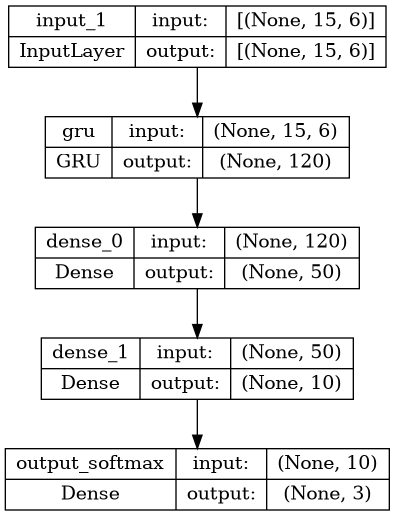

In [8]:
plot_model(model, show_shapes=True, show_layer_names=True)

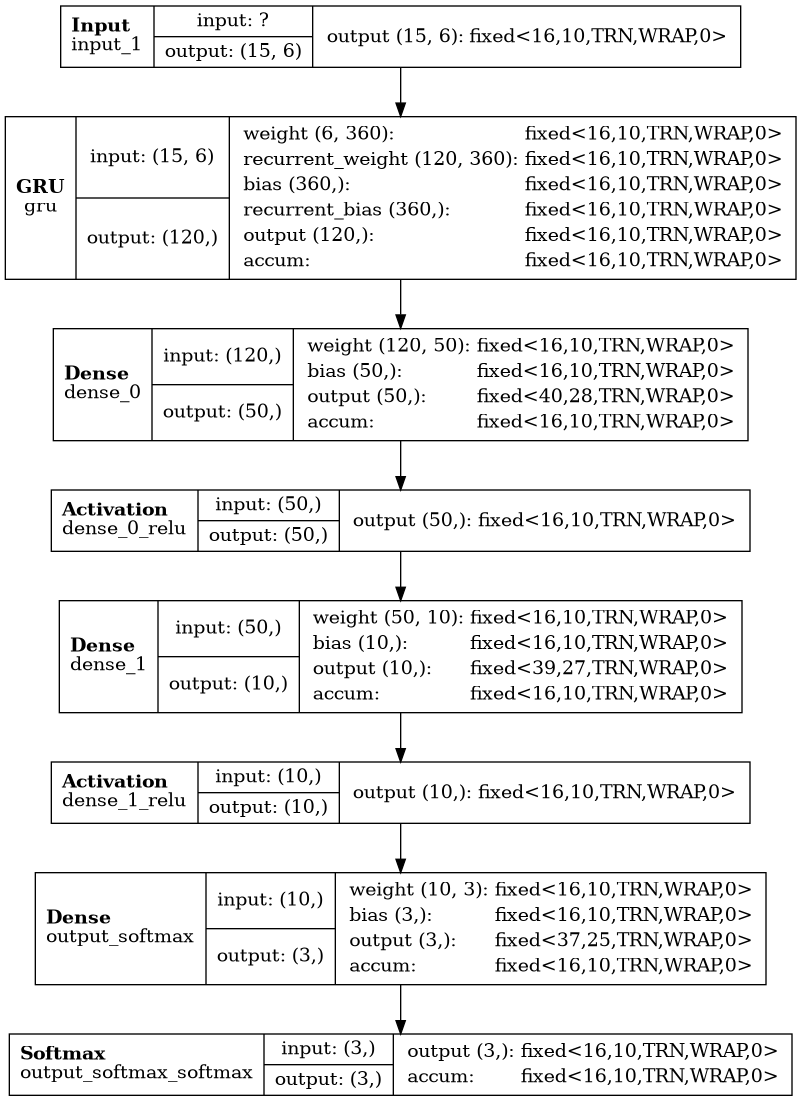

In [9]:
# create hls4ml model
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='name', default_precision='ap_fixed<16,10>')

for layer in config['LayerName'].keys():
    config['LayerName'][layer]['Trace'] = True

hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vivado', output_dir='ftag_hls4ml_model', part='xc7vx690tffg1761-2'
)

hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [10]:
hls_model.compile()

In [11]:
X_testzero = np.zeros((1, 15, 6))
X_testzero_contig = np.ascontiguousarray(X_testzero)
y_hls_predict, y_hls_trace =  hls_model.trace(X_testzero_contig)

Recompiling myproject with tracing


In [12]:
print(y_hls_predict)
print(y_hls_trace)

[0.328125 0.328125 0.328125]
{'gru': array([[-0.8125  ,  0.015625, -0.6875  , -1.      ,  0.015625, -0.328125,
        -0.25    , -0.09375 , -0.46875 , -0.296875, -0.265625, -0.109375,
        -0.125   , -0.265625, -0.328125, -0.734375, -0.390625,  0.1875  ,
        -0.453125, -0.265625, -0.53125 , -0.078125, -0.34375 , -0.421875,
        -0.1875  ,  0.28125 , -0.53125 ,  0.125   ,  0.140625, -0.078125,
        -0.8125  ,  0.3125  ,  0.15625 , -0.015625, -0.65625 ,  0.40625 ,
        -0.03125 , -0.203125, -0.171875,  0.4375  , -0.953125, -0.71875 ,
        -0.78125 ,  0.015625, -0.78125 , -0.09375 , -0.21875 , -0.640625,
        -0.953125,  0.859375, -0.515625, -0.234375, -0.453125, -0.296875,
        -0.296875, -0.953125, -0.109375, -0.328125, -0.796875, -0.875   ,
        -0.53125 ,  0.109375, -0.140625, -0.953125, -0.046875, -0.109375,
         0.171875, -0.4375  , -0.3125  , -0.765625, -0.125   , -0.890625,
        -0.71875 , -0.1875  ,  0.03125 , -0.140625, -0.65625 , -0.484375,
 